In [ ]:
import pandas as pd
from google.colab import drive
import numpy as np
from scipy.stats import chi2
import statsmodels.api as sm
from scipy.stats import ttest_ind

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = 'data_b1_b2_title.xlsx'
data = pd.read_excel(file_path)

In [ ]:
from statsmodels.formula.api import ols
model_Title = ols('noabsDifference ~  TitleLabel', data).fit()
anova_result = sm.stats.anova_lm(model_Title)
print("ANOVA Result:")
print(anova_result)

ANOVA Result:
               df      sum_sq    mean_sq          F    PR(>F)
TitleLabel    2.0   25.204913  12.602457  10.358168  0.000042
Residual    357.0  434.350643   1.216668        NaN       NaN


In [ ]:
males = data.loc[data['TitleLabel'] == 'Doctor', 'noabsDifference']
females = data.loc[data['TitleLabel'] == 'Non title', 'noabsDifference']

t_statistic, p_value = ttest_ind(males, females, equal_var=False)
print("Welch's t-test:")
print("T-statistic:", t_statistic)
print("P-value:", p_value)

Welch's t-test:
T-statistic: 3.8326576035682507
P-value: 0.0001710791032489215


In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
model = sm.formula.ols('noabsDifference ~ TitleLabel', data=data).fit()
anova_result = sm.stats.anova_lm(model)
tukey_result = pairwise_tukeyhsd(data['noabsDifference'], data['TitleLabel'])

# Display ANOVA
print("ANOVA Result:")
print(anova_result)

# Display the Tukey's HSD test result
print("\nTukey's HSD Test Result:")
print(tukey_result)

ANOVA Result:
               df      sum_sq    mean_sq          F    PR(>F)
TitleLabel    2.0   25.204913  12.602457  10.358168  0.000042
Residual    357.0  434.350643   1.216668        NaN       NaN

Tukey's HSD Test Result:
  Multiple Comparison of Means - Tukey HSD, FWER=0.05  
group1   group2  meandiff p-adj   lower   upper  reject
-------------------------------------------------------
Doctor        MD   0.0694 0.8741  -0.261  0.3997  False
Doctor Non title  -0.5323 0.0007 -0.8699 -0.1946   True
    MD Non title  -0.6016 0.0001 -0.9399 -0.2634   True
-------------------------------------------------------


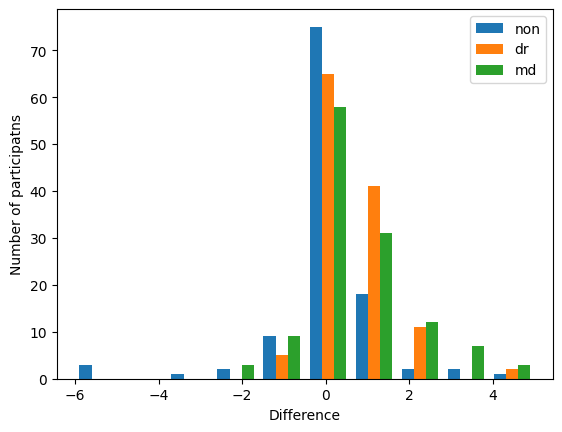

In [ ]:
import matplotlib.pyplot as plt
Non = data['Non']
Dr = data['Dr']
MD = data['MD']
cleaned_non = [x for x in Non if not np.isnan(x)]
cleaned_dr = [x for x in Dr if not np.isnan(x)]
cleaned_md = [x for x in MD if not np.isnan(x)]
x = [cleaned_non, cleaned_dr, cleaned_md]
fig, ax = plt.subplots()
ax.hist(x, label = ['non', 'dr', 'md'])
plt.xlabel("Difference")
plt.ylabel("Number of participatns")
plt.legend()
plt.show()

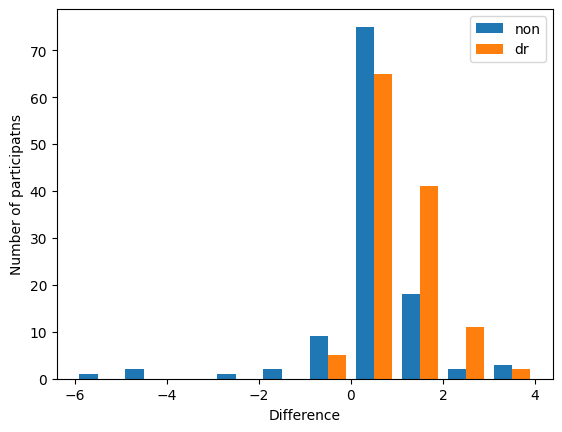

In [ ]:
y = [cleaned_non, cleaned_dr]
fig, ax = plt.subplots()
ax.hist(y, label = ['non', 'dr'])
plt.xlabel("Difference")
plt.ylabel("Number of participatns")
plt.legend()
plt.show()